# ECON N171: Economic Development
## Lecture 5 — Data Visualization: Matplotlib and Seaborn
**Instructor: Rajveer Jat | Summer 2026**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. Build publication-quality plots using **Matplotlib** and **Seaborn**
2. Choose the right chart type for your data and research question
3. Plot **distributions**, **scatter plots**, **time series**, and **bar charts**
4. Add proper **labels, titles, and annotations** to communicate findings
5. Create **multi-panel figures** — the standard in academic papers

> 💡 Run each cell with `Shift + Enter` and follow along.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set a clean style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Cross-sectional dataset (2022)
data = {
    'country'       : ['USA', 'France', 'Japan', 'UAE',
                       'Brazil', 'Mexico', 'South Korea',
                       'Vietnam', 'Nigeria', 'Ghana',
                       'Ethiopia', 'Kenya'],
    'region'        : ['North America', 'Europe', 'East Asia', 'Middle East',
                       'Latin America', 'Latin America', 'East Asia',
                       'East Asia', 'Sub-Saharan Africa', 'Sub-Saharan Africa',
                       'Sub-Saharan Africa', 'Sub-Saharan Africa'],
    'income_group'  : ['High', 'High', 'High', 'High',
                       'Upper-Middle', 'Upper-Middle', 'High',
                       'Lower-Middle', 'Lower-Middle', 'Lower-Middle',
                       'Low', 'Low'],
    'gdp_per_capita': [76399, 40886, 33815, 49532,
                        9001,  9926, 32255,
                        4163,  2066,  2363,
                         925,  1838],
    'population'    : [333, 68, 125, 10,
                       215, 128, 52,
                        97, 219, 32,
                       123, 54],   # millions
    'poverty_rate'  : [1.2, 0.1, 0.7, 0.0,
                       5.8, 7.3, 0.2,
                       1.5, 39.1, 24.8,
                       26.1, 36.1],
    'growth_rate'   : [2.0, 2.5, 1.5, 3.5,
                       3.0, 2.5, 2.7,
                       6.1, 3.2, 3.8,
                       7.0, 5.2],
    'literacy_rate' : [99.0, 99.0, 99.0, 97.0,
                       93.2, 95.2, 99.0,
                       95.8, 62.0, 79.0,
                       52.1, 82.0]
}
df = pd.DataFrame(data)
df['log_gdp'] = np.log(df['gdp_per_capita'])

# Time series dataset (2010-2022)
countries_ts = ['USA', 'China', 'Vietnam', 'Nigeria', 'Ethiopia']
years = list(range(2010, 2023))
gdp_ts = {
    'USA'      : [48374, 49791, 51450, 52782, 54657, 56443, 57867, 59927, 62996, 65298, 63544, 70149, 76399],
    'China'    : [ 4550,  5618,  6300,  7050,  7651,  8028,  8117,  8879,  9977, 10217, 10408, 12556, 12813],
    'Vietnam'  : [ 1310,  1543,  1755,  1908,  2052,  2109,  2194,  2342,  2563,  2715,  2786,  3756,  4163],
    'Nigeria'  : [ 2300,  2459,  2753,  3005,  3217,  2731,  2177,  1968,  2028,  2097,  2097,  2085,  2066],
    'Ethiopia' : [  357,   394,   466,   518,   565,   619,   691,   768,   853,   936,   925,   925,   925],
}

ts_rows = []
for country, vals in gdp_ts.items():
    for yr, val in zip(years, vals):
        ts_rows.append({'country': country, 'year': yr, 'gdp_per_capita': val})
ts = pd.DataFrame(ts_rows)

print("Datasets ready.")

Datasets ready.


---
## Part 1: The Grammar of a Plot

Every Matplotlib figure has the same structure:
- **Figure** — the overall canvas
- **Axes** — the individual plot area (one figure can have many axes)
- **Artists** — lines, bars, points, text, labels

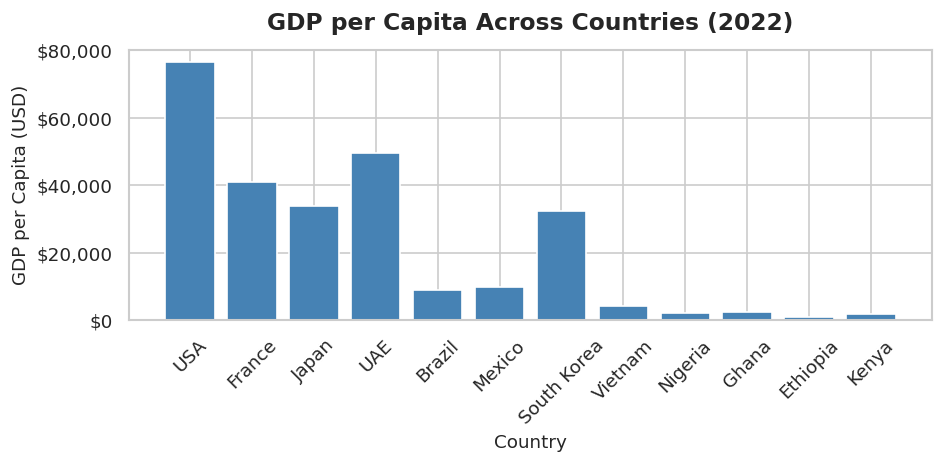

In [3]:
# Anatomy of a plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(df['country'], df['gdp_per_capita'], color='steelblue', edgecolor='white')

ax.set_title('GDP per Capita Across Countries (2022)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Country', fontsize=11)
ax.set_ylabel('GDP per Capita (USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Part 2: Bar Charts — Comparing Across Countries

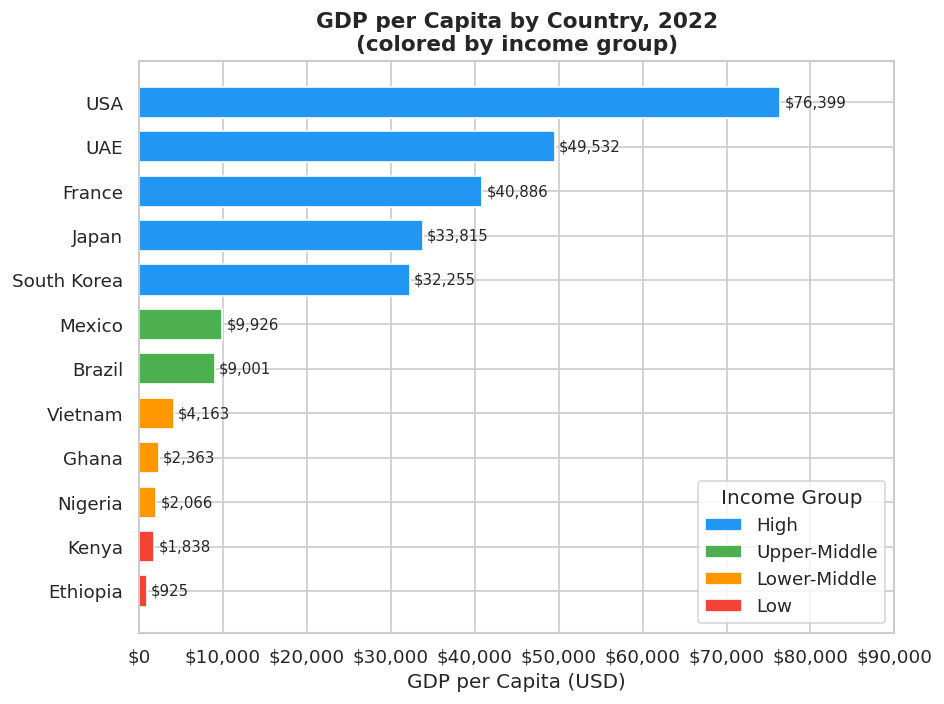

In [4]:
# Sorted horizontal bar chart — cleaner for many countries
df_sorted = df.sort_values('gdp_per_capita', ascending=True)

# Color by income group
color_map = {'High': '#2196F3', 'Upper-Middle': '#4CAF50',
             'Lower-Middle': '#FF9800', 'Low': '#F44336'}
colors = df_sorted['income_group'].map(color_map)

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(df_sorted['country'], df_sorted['gdp_per_capita'],
               color=colors, edgecolor='white', height=0.7)

# Add value labels at end of each bar
for bar, val in zip(bars, df_sorted['gdp_per_capita']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

ax.set_title('GDP per Capita by Country, 2022\n(colored by income group)', fontsize=13, fontweight='bold')
ax.set_xlabel('GDP per Capita (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(0, 90000)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_elements, loc='lower right', title='Income Group')

plt.tight_layout()
plt.show()

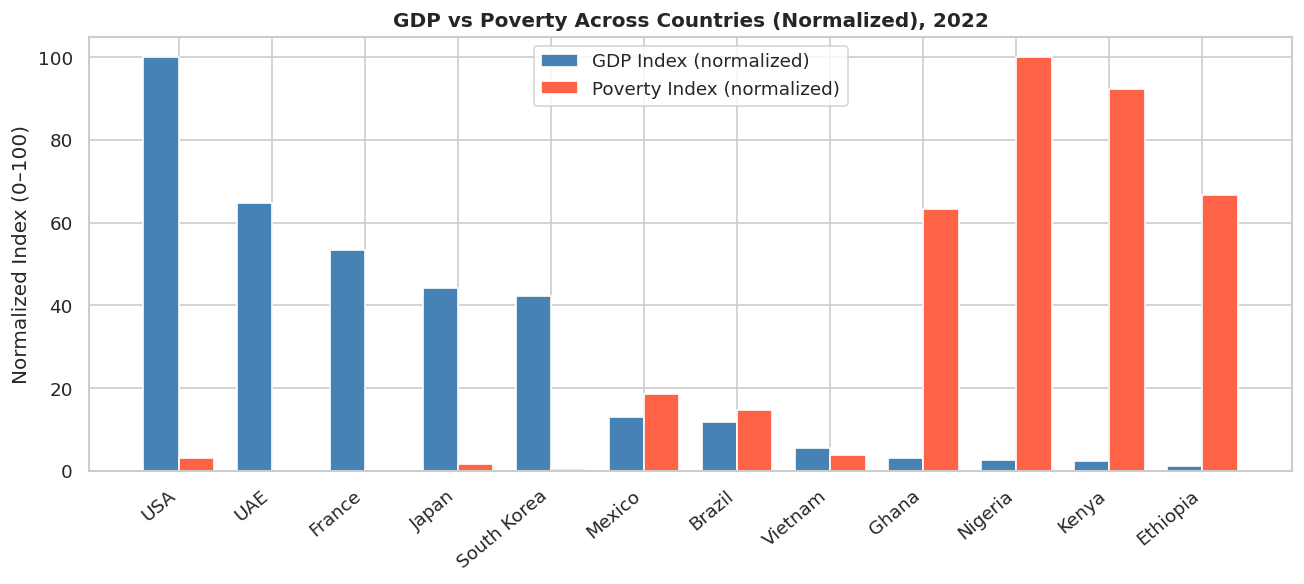

In [5]:
# Grouped bar chart: GDP vs poverty side by side (normalized)
# Normalize both to 0-100 scale for comparison
df_plot = df.sort_values('gdp_per_capita', ascending=False).copy()
df_plot['gdp_norm']     = df_plot['gdp_per_capita'] / df_plot['gdp_per_capita'].max() * 100
df_plot['poverty_norm'] = df_plot['poverty_rate']   / df_plot['poverty_rate'].max()   * 100

x = np.arange(len(df_plot))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, df_plot['gdp_norm'],     w, label='GDP Index (normalized)', color='steelblue')
ax.bar(x + w/2, df_plot['poverty_norm'], w, label='Poverty Index (normalized)', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(df_plot['country'], rotation=40, ha='right')
ax.set_ylabel('Normalized Index (0–100)')
ax.set_title('GDP vs Poverty Across Countries (Normalized), 2022', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

---
## Part 3: Scatter Plots — The Core Tool of Empirical Economics

Scatter plots show the **relationship between two variables**.  
In development economics, the most important scatter plot is **log GDP vs poverty rate** — the Preston Curve.

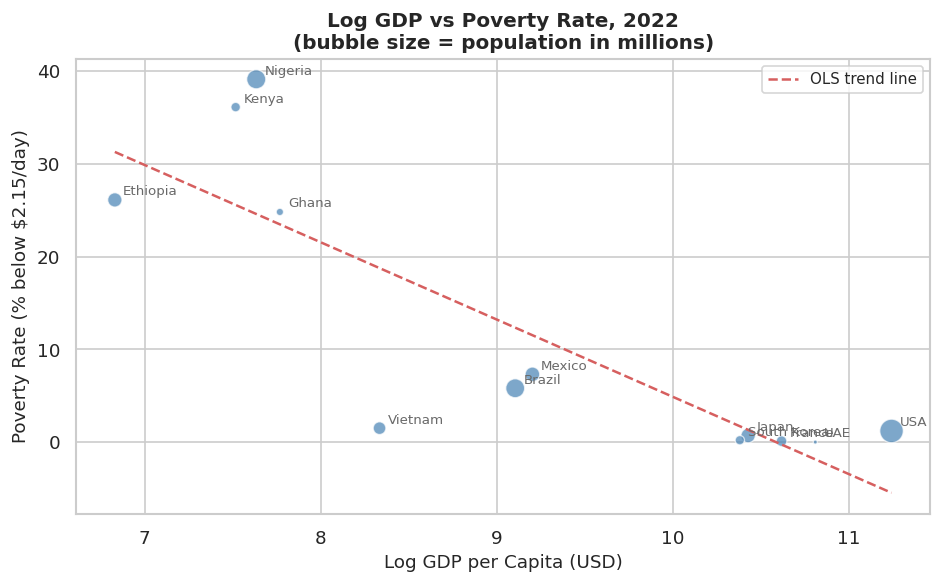

In [6]:
# Basic scatter: log GDP vs poverty rate
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['log_gdp'], df['poverty_rate'],
           s=df['population'] * 0.6,   # bubble size = population
           alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.8)

# Label each point
for _, row in df.iterrows():
    ax.annotate(row['country'],
                xy=(row['log_gdp'], row['poverty_rate']),
                xytext=(5, 3), textcoords='offset points',
                fontsize=8, color='dimgray')

# Add a trend line
z = np.polyfit(df['log_gdp'], df['poverty_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['log_gdp'].min(), df['log_gdp'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='OLS trend line')

ax.set_xlabel('Log GDP per Capita (USD)', fontsize=11)
ax.set_ylabel('Poverty Rate (% below $2.15/day)', fontsize=11)
ax.set_title('Log GDP vs Poverty Rate, 2022\n(bubble size = population in millions)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

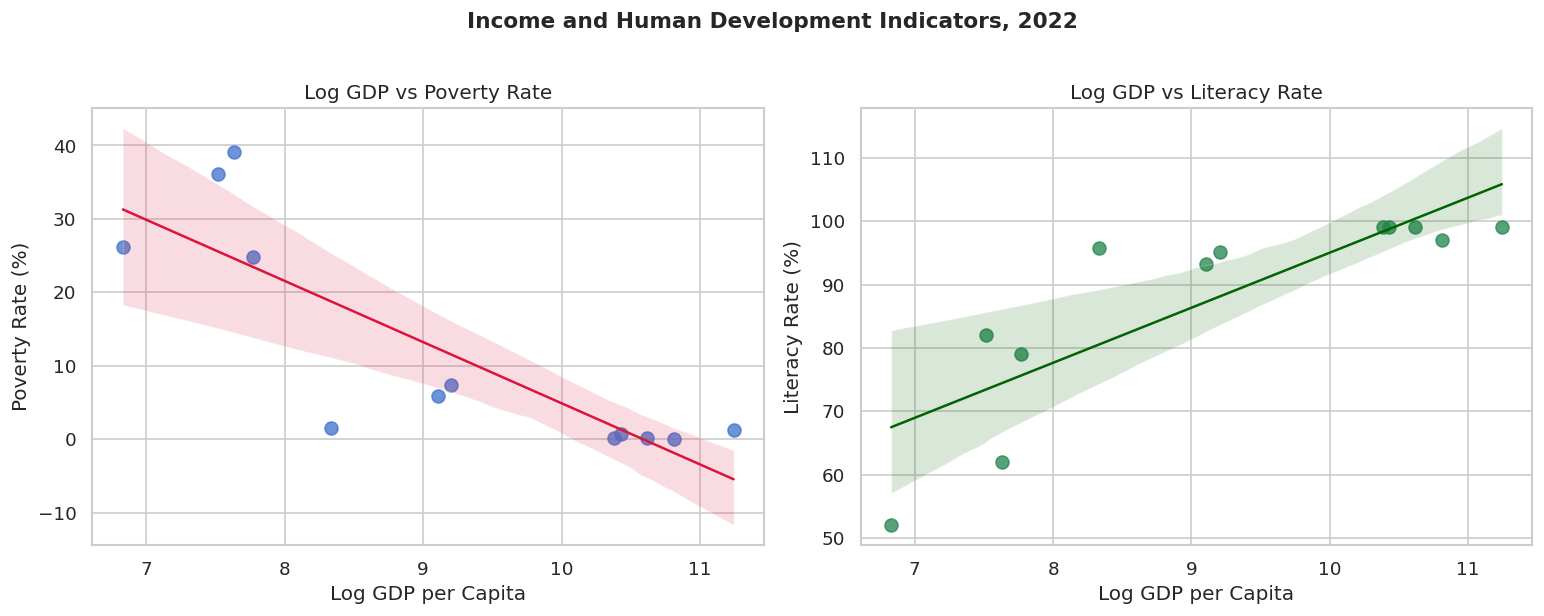

In [7]:
# Seaborn scatter with regression line — one line of code
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: log GDP vs poverty
sns.regplot(data=df, x='log_gdp', y='poverty_rate',
            scatter_kws={'s': 60, 'alpha': 0.8},
            line_kws={'color': 'crimson', 'linewidth': 1.5},
            ax=axes[0])
axes[0].set_xlabel('Log GDP per Capita')
axes[0].set_ylabel('Poverty Rate (%)')
axes[0].set_title('Log GDP vs Poverty Rate')

# Right: log GDP vs literacy
sns.regplot(data=df, x='log_gdp', y='literacy_rate',
            scatter_kws={'s': 60, 'alpha': 0.8, 'color': 'seagreen'},
            line_kws={'color': 'darkgreen', 'linewidth': 1.5},
            ax=axes[1])
axes[1].set_xlabel('Log GDP per Capita')
axes[1].set_ylabel('Literacy Rate (%)')
axes[1].set_title('Log GDP vs Literacy Rate')

plt.suptitle('Income and Human Development Indicators, 2022',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 4: Time Series — Tracking Development Over Time

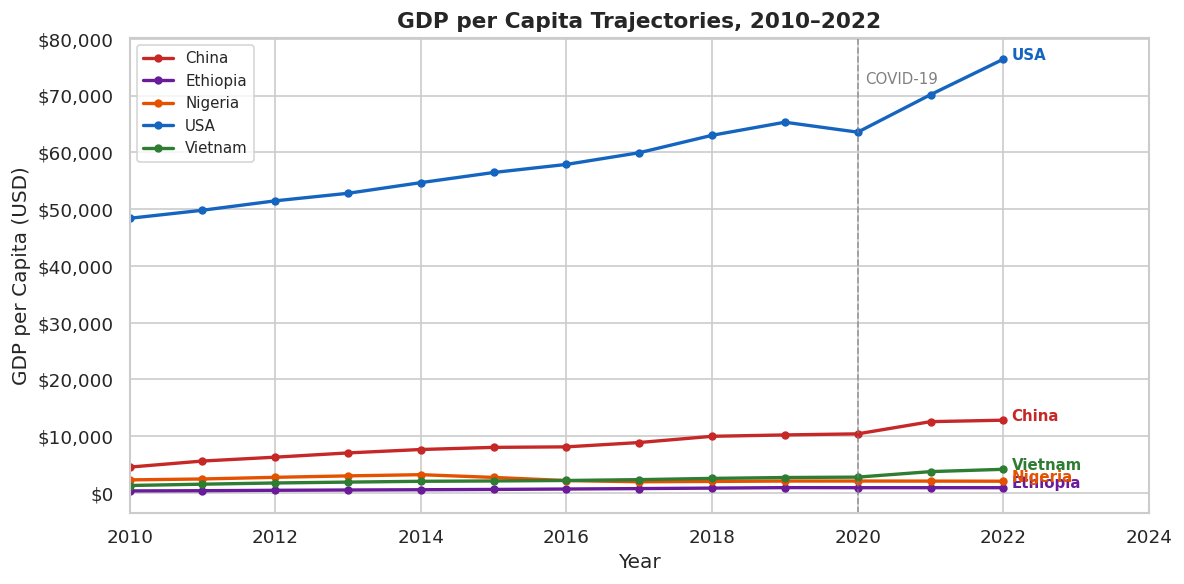

In [8]:
# GDP per capita over time for selected countries
palette = {
    'USA'      : '#1565C0',
    'China'    : '#C62828',
    'Vietnam'  : '#2E7D32',
    'Nigeria'  : '#E65100',
    'Ethiopia' : '#6A1B9A'
}

fig, ax = plt.subplots(figsize=(10, 5))

for country, group in ts.groupby('country'):
    ax.plot(group['year'], group['gdp_per_capita'],
            marker='o', markersize=4,
            color=palette[country],
            label=country, linewidth=2)

    # Label at the end of each line
    last = group[group['year'] == group['year'].max()].iloc[0]
    ax.annotate(country,
                xy=(last['year'], last['gdp_per_capita']),
                xytext=(5, 0), textcoords='offset points',
                fontsize=9, color=palette[country], fontweight='bold')

ax.set_xlabel('Year')
ax.set_ylabel('GDP per Capita (USD)')
ax.set_title('GDP per Capita Trajectories, 2010–2022', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(2010, 2024)
ax.legend(loc='upper left', fontsize=9)

# Mark COVID year
ax.axvline(x=2020, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(2020.1, ax.get_ylim()[1]*0.9, 'COVID-19', color='gray', fontsize=9)

plt.tight_layout()
plt.show()

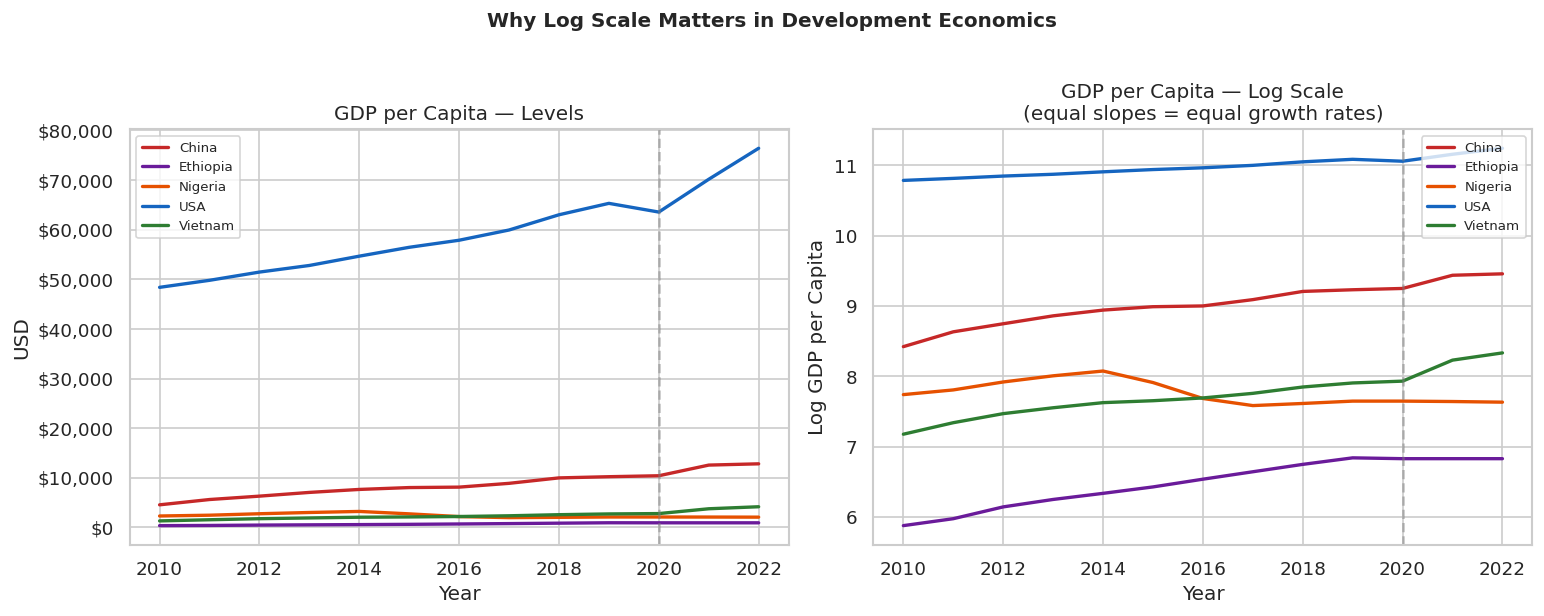

In [9]:
# Growth rate time series — log scale reveals proportional growth
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: levels
for country, group in ts.groupby('country'):
    axes[0].plot(group['year'], group['gdp_per_capita'],
                 label=country, color=palette[country], linewidth=2)
axes[0].set_title('GDP per Capita — Levels')
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(fontsize=8)

# Right: log scale
for country, group in ts.groupby('country'):
    axes[1].plot(group['year'], np.log(group['gdp_per_capita']),
                 label=country, color=palette[country], linewidth=2)
axes[1].set_title('GDP per Capita — Log Scale\n(equal slopes = equal growth rates)')
axes[1].set_ylabel('Log GDP per Capita')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('Year')
    ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Why Log Scale Matters in Development Economics',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 5: Distributions

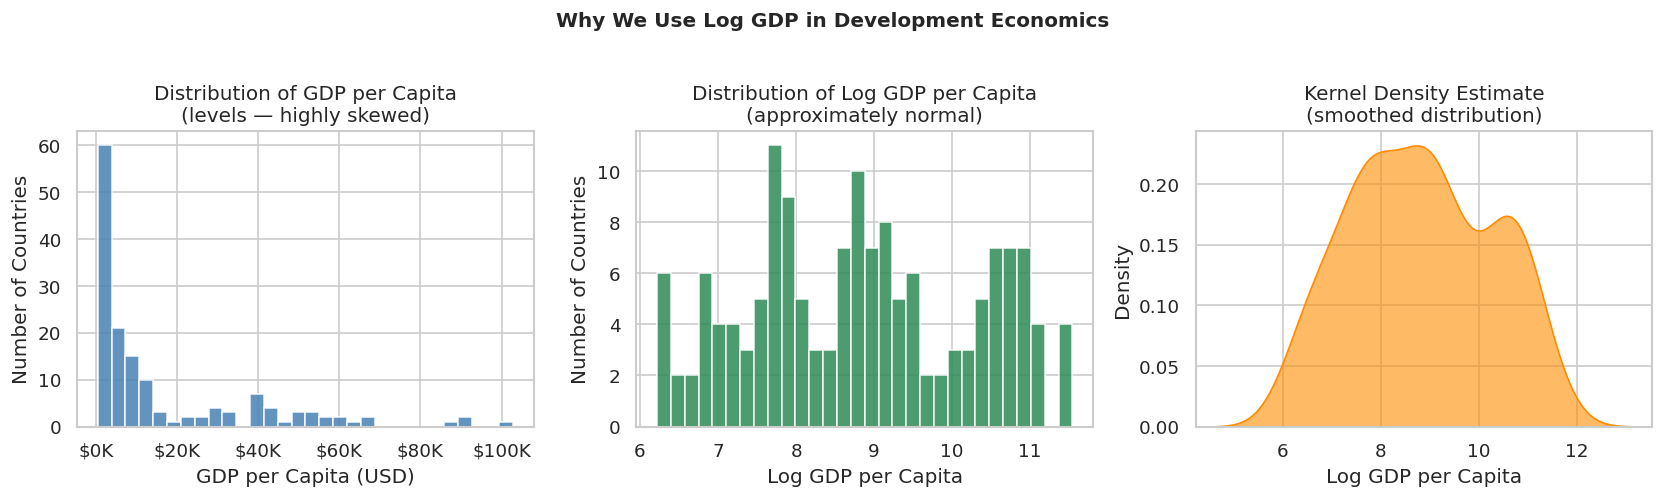

In [10]:
# Generate a larger synthetic cross-country GDP dataset to show distributions
np.random.seed(42)
n = 150
log_gdp_synthetic = np.concatenate([
    np.random.normal(10.8, 0.4, 40),   # high income
    np.random.normal(9.0,  0.5, 50),   # upper-middle
    np.random.normal(7.8,  0.4, 40),   # lower-middle
    np.random.normal(6.7,  0.3, 20),   # low income
])
gdp_synthetic = np.exp(log_gdp_synthetic)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogram of GDP levels
axes[0].hist(gdp_synthetic, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of GDP per Capita\n(levels — highly skewed)')
axes[0].set_xlabel('GDP per Capita (USD)')
axes[0].set_ylabel('Number of Countries')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Histogram of log GDP
axes[1].hist(log_gdp_synthetic, bins=30, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Log GDP per Capita\n(approximately normal)')
axes[1].set_xlabel('Log GDP per Capita')
axes[1].set_ylabel('Number of Countries')

# KDE (density) plot
sns.kdeplot(log_gdp_synthetic, ax=axes[2], fill=True, color='darkorange', alpha=0.6)
axes[2].set_title('Kernel Density Estimate\n(smoothed distribution)')
axes[2].set_xlabel('Log GDP per Capita')
axes[2].set_ylabel('Density')

plt.suptitle('Why We Use Log GDP in Development Economics',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## Part 6: Seaborn — Statistical Visualization in One Line

/tmp/ipykernel_562/2244055230.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=expanded, x='income_group', y='gdp_per_capita',
/tmp/ipykernel_562/2244055230.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=expanded, x='income_group', y='poverty_rate',


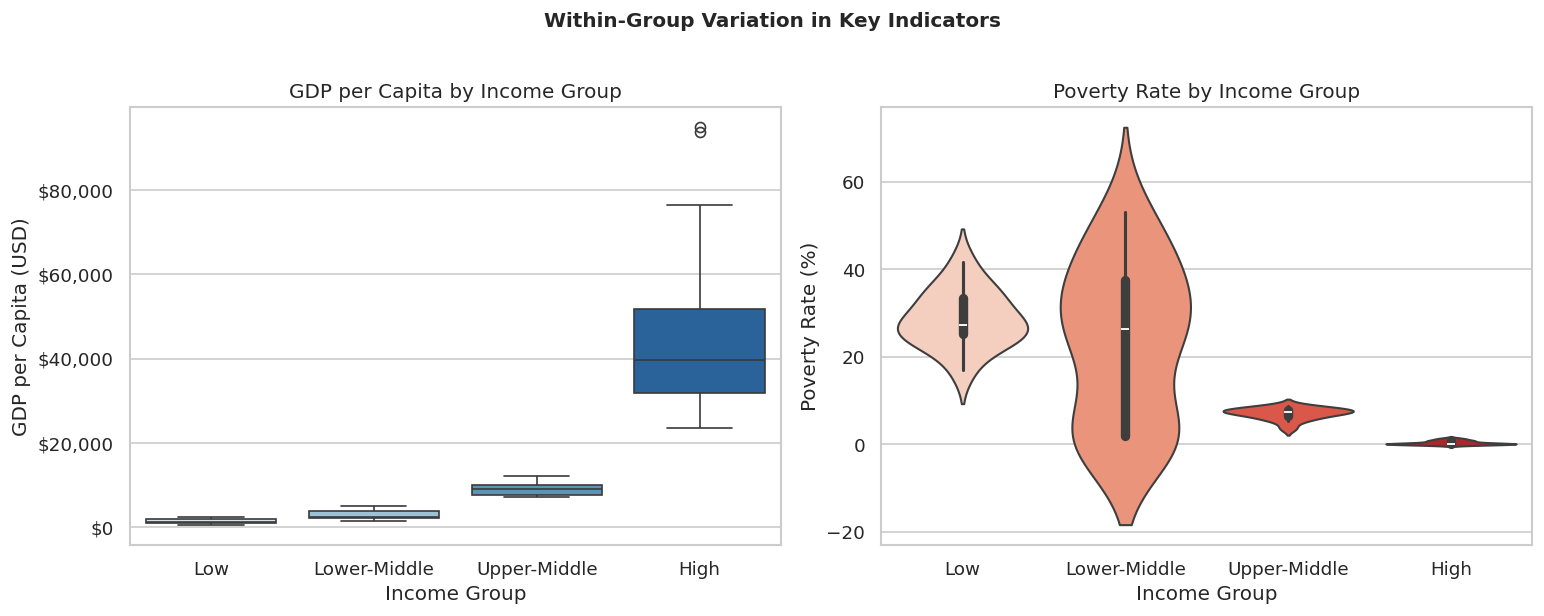

In [11]:
# Box plot: GDP distribution by income group
# Expand our dataset by adding noise to simulate more countries per group
np.random.seed(1)
expanded_rows = []
base = df[['income_group', 'gdp_per_capita', 'poverty_rate', 'growth_rate']].copy()
for _ in range(6):
    temp = base.copy()
    temp['gdp_per_capita'] *= np.random.uniform(0.7, 1.3, len(temp))
    temp['poverty_rate']   *= np.random.uniform(0.6, 1.4, len(temp))
    expanded_rows.append(temp)
expanded = pd.concat([base] + expanded_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
sns.boxplot(data=expanded, x='income_group', y='gdp_per_capita',
            order=order, palette='Blues', ax=axes[0])
axes[0].set_title('GDP per Capita by Income Group')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('GDP per Capita (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Violin plot
sns.violinplot(data=expanded, x='income_group', y='poverty_rate',
               order=order, palette='Reds', ax=axes[1])
axes[1].set_title('Poverty Rate by Income Group')
axes[1].set_xlabel('Income Group')
axes[1].set_ylabel('Poverty Rate (%)')

plt.suptitle('Within-Group Variation in Key Indicators', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

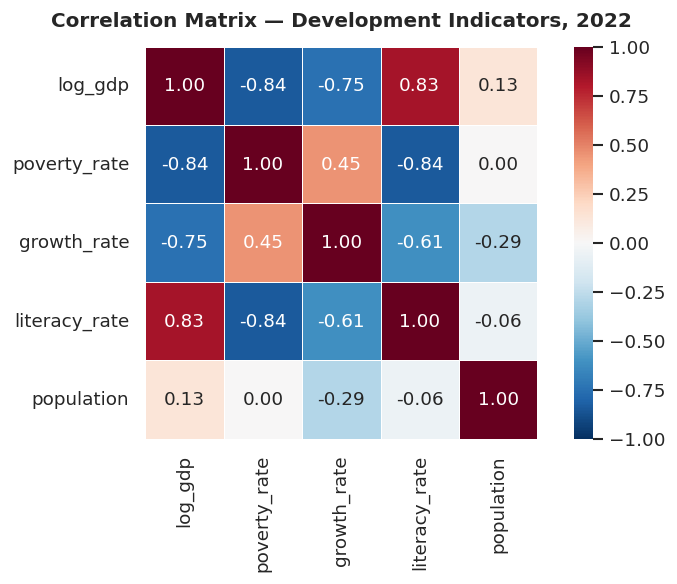

In [12]:
# Heatmap: correlation matrix of development indicators
corr_vars = df[['log_gdp', 'poverty_rate', 'growth_rate', 'literacy_rate', 'population']]
corr_matrix = corr_vars.corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            ax=ax)
ax.set_title('Correlation Matrix — Development Indicators, 2022',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## Part 7: Multi-Panel Publication Figure

Academic papers use multi-panel figures. Let's build one from scratch — the kind you would see in a JDE paper.

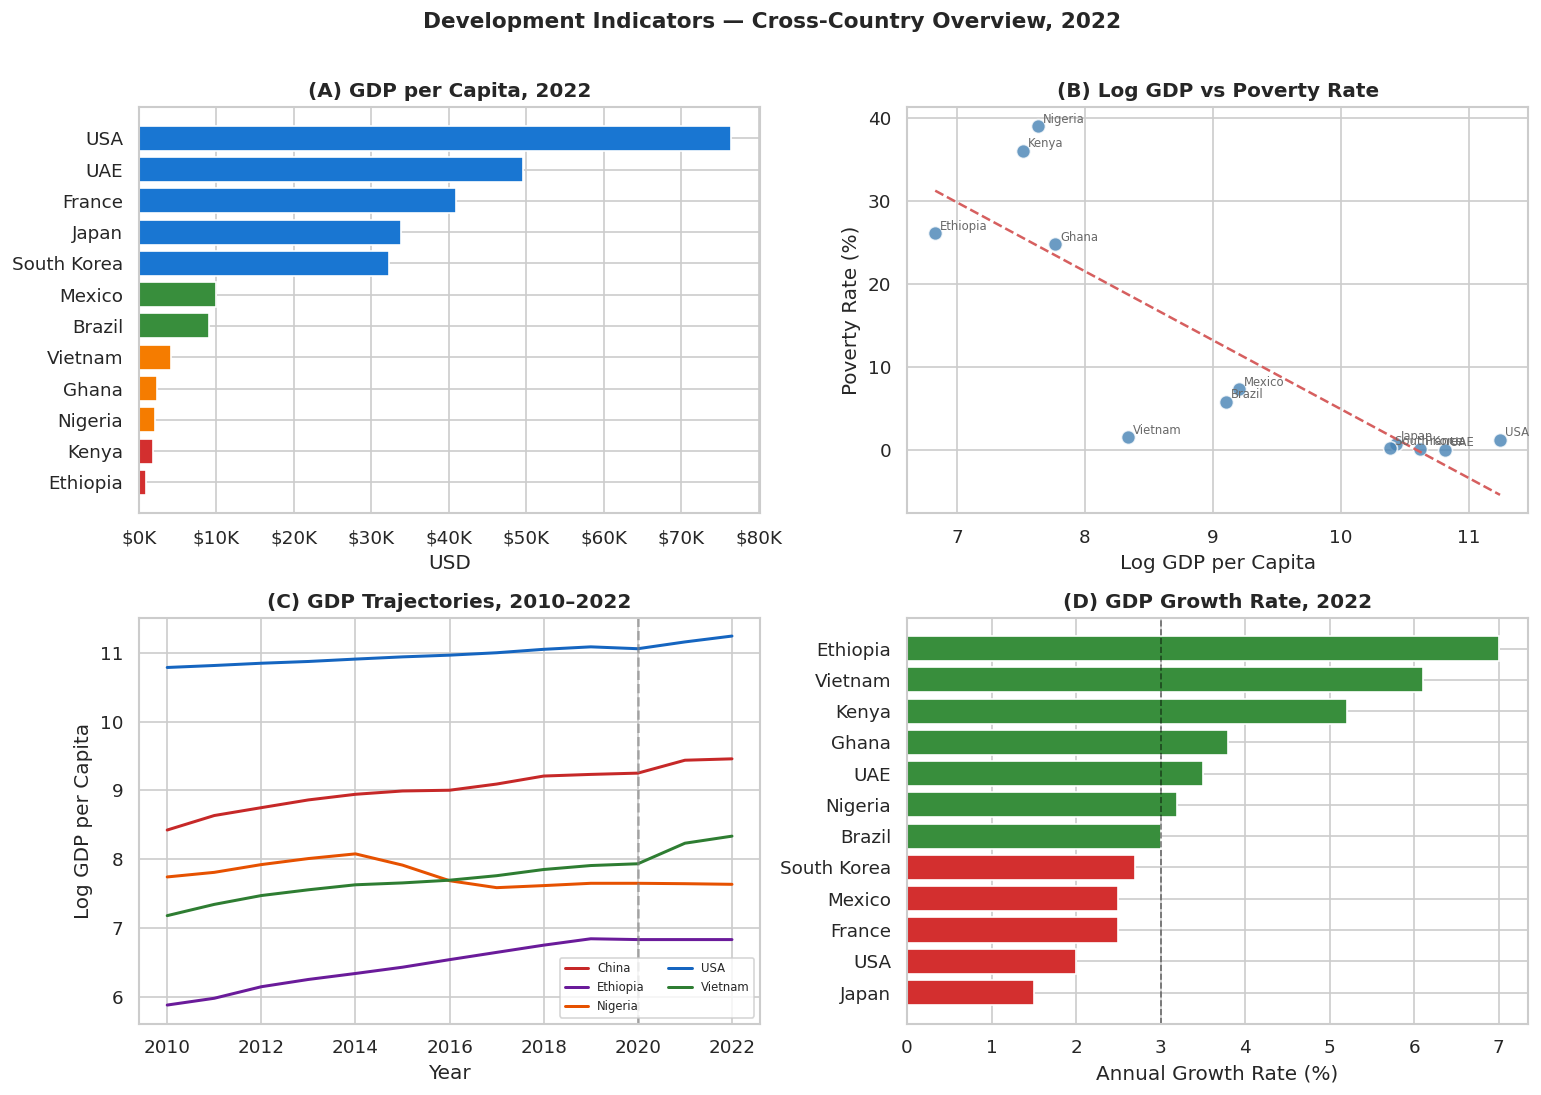

Figure saved as development_overview.png


In [13]:
fig = plt.figure(figsize=(13, 9))

# 2x2 grid
ax1 = fig.add_subplot(2, 2, 1)   # top-left
ax2 = fig.add_subplot(2, 2, 2)   # top-right
ax3 = fig.add_subplot(2, 2, 3)   # bottom-left
ax4 = fig.add_subplot(2, 2, 4)   # bottom-right

# Panel A: horizontal bar — GDP per capita
df_s = df.sort_values('gdp_per_capita')
colors_a = df_s['income_group'].map({'High':'#1976D2','Upper-Middle':'#388E3C',
                                      'Lower-Middle':'#F57C00','Low':'#D32F2F'})
ax1.barh(df_s['country'], df_s['gdp_per_capita'], color=colors_a, edgecolor='white')
ax1.set_xlabel('USD')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.set_title('(A) GDP per Capita, 2022', fontweight='bold')

# Panel B: scatter — log GDP vs poverty
ax2.scatter(df['log_gdp'], df['poverty_rate'],
            s=70, color='steelblue', alpha=0.8, edgecolors='white')
for _, row in df.iterrows():
    ax2.annotate(row['country'], (row['log_gdp'], row['poverty_rate']),
                 fontsize=7, xytext=(3, 2), textcoords='offset points', color='dimgray')
z = np.polyfit(df['log_gdp'], df['poverty_rate'], 1)
x_l = np.linspace(df['log_gdp'].min(), df['log_gdp'].max(), 100)
ax2.plot(x_l, np.poly1d(z)(x_l), 'r--', linewidth=1.5)
ax2.set_xlabel('Log GDP per Capita')
ax2.set_ylabel('Poverty Rate (%)')
ax2.set_title('(B) Log GDP vs Poverty Rate', fontweight='bold')

# Panel C: time series
for country, group in ts.groupby('country'):
    ax3.plot(group['year'], np.log(group['gdp_per_capita']),
             label=country, color=palette[country], linewidth=1.8)
ax3.axvline(2020, color='gray', linestyle='--', alpha=0.6)
ax3.set_xlabel('Year')
ax3.set_ylabel('Log GDP per Capita')
ax3.set_title('(C) GDP Trajectories, 2010–2022', fontweight='bold')
ax3.legend(fontsize=7, ncol=2)

# Panel D: bar chart — growth rates
df_g = df.sort_values('growth_rate', ascending=True)
bar_colors = ['#D32F2F' if g < 3 else '#388E3C' for g in df_g['growth_rate']]
ax4.barh(df_g['country'], df_g['growth_rate'], color=bar_colors, edgecolor='white')
ax4.axvline(x=3, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_xlabel('Annual Growth Rate (%)')
ax4.set_title('(D) GDP Growth Rate, 2022', fontweight='bold')

plt.suptitle('Development Indicators — Cross-Country Overview, 2022',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('development_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as development_overview.png")

---
## 📌 Summary

| Chart Type | When to Use | Matplotlib/Seaborn |
|------------|-------------|--------------------|
| Bar chart | Compare across categories | `ax.bar()`, `ax.barh()` |
| Scatter plot | Relationship between two variables | `ax.scatter()`, `sns.regplot()` |
| Line plot | Change over time | `ax.plot()` |
| Histogram | Distribution of one variable | `ax.hist()` |
| KDE | Smoothed distribution | `sns.kdeplot()` |
| Box/Violin | Distribution by group | `sns.boxplot()`, `sns.violinplot()` |
| Heatmap | Correlation matrix | `sns.heatmap()` |
| Multi-panel | Full paper figure | `fig.add_subplot()` |

**Next lecture:** EDA — Exploratory Data Analysis using the Gollin et al (QJE 2014) dataset.

---
*ECON N171 | Summer 2026*